# Olist — ventes, livraison et satisfaction

Etude exploratoire reproductible pour un portfolio Data Analyst. Les résultats sont calculés sur les fichiers locaux.

Exécuter d'abord `python scripts/run_analysis.py` depuis `portfolio`, puis ouvrir ce notebook. Il présente la lecture des sources, les contrôles, SQL, Python et l'interprétation. Les 26 hypothèses détaillées figurent dans le rapport et `data/hypotheses.csv`.

Source : [Olist sur Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Les résultats décrivent cet extrait historique, sans causalité démontrée.

In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
from scipy import stats

# Trouver le projet depuis le dossier portfolio ou notebooks.
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/run_metadata.json').exists())
import os
ROOT = Path(os.environ.get('OLIST_RAW_DIR', str(BASE / 'data/raw')))
conn = sqlite3.connect(BASE / 'olist_portfolio.sqlite')
orders = pd.read_csv(ROOT / 'olist_orders_dataset.csv', dtype=str)
items = pd.read_csv(ROOT / 'olist_order_items_dataset.csv')
print('Commandes :', len(orders), '| Articles :', len(items))
print(orders[['order_id', 'order_status']].head().to_string(index=False))
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})


Commandes : 99441 | Articles : 112650
                        order_id order_status
e481f51cbdc54678b7cc49136f2d6af7    delivered
53cdb2fc8bc7dce0b6741e2150273451    delivered
47770eb9100c2d0c44946d9cf07ec65d    delivered
949d5b44dbf5de918fe9c16f97b45f8a    delivered
ad21c59c0840e6cb83a9ceb5573f8159    delivered


## 1. Le grain des données

Une commande peut avoir plusieurs articles, paiements et avis. Joindre les trois tables enfants directement multiplie les lignes. On agrège séparément avant la jointure. `customer_unique_id` est utilisé pour suivre un client entre commandes.

In [2]:
assert orders.order_id.is_unique
assert not items.duplicated(['order_id', 'order_item_id']).any()
print('Clés des commandes et des articles : valides')
quality = pd.read_csv(BASE / 'data/quality_checks.csv')
print(quality[quality.valeur > 0].to_string(index=False))

Clés des commandes et des articles : valides
                                  controle  valeur                                                                         traitement
             Commandes avec plusieurs avis     547 Dernier avis par date de reponse, puis creation, puis review_id, puis ordre source
                        Doublons review_id     814                                               review_id non utilise seul comme cle
                   Commandes sans articles     775                                                         Montants laisses manquants
                   Commandes sans paiement       1                                                         Montants laisses manquants
                       Commandes sans avis     768                                                      Exclues des moyennes de notes
            Livrees sans date de reception       8                                                                 Exclues des delais
     Remise trans

## 2. Une première analyse en SQL

GMV = somme des prix des articles de commandes livrées, hors port. Ce n'est ni le revenu net d'Olist ni une marge. Période d'achat principale : janvier 2017 à août 2018. Les dates et statuts finaux proviennent de l'extrait disponible.

In [3]:
query = """
SELECT purchase_month, COUNT(*) AS orders,
       ROUND(SUM(item_value),2) AS gmv_brl,
       ROUND(AVG(item_value),2) AS basket_brl
FROM fact_orders
WHERE analysis_period=1 AND order_status='delivered'
GROUP BY purchase_month ORDER BY purchase_month;
"""
monthly = pd.read_sql_query(query, conn)
print(monthly.to_string(index=False))

purchase_month  orders   gmv_brl  basket_brl
       2017-01     750 111798.36      149.06
       2017-02    1653 234223.40      141.70
       2017-03    2546 359198.85      141.08
       2017-04    2303 340669.68      147.92
       2017-05    3546 489338.25      138.00
       2017-06    3135 421923.37      134.58
       2017-07    3872 481604.52      124.38
       2017-08    4193 554699.70      132.29
       2017-09    4150 607399.67      146.36
       2017-10    4478 648247.65      144.76
       2017-11    7289 987765.37      135.51
       2017-12    5513 726033.19      131.69
       2018-01    7069 924645.00      130.80
       2018-02    6555 826437.13      126.08
       2018-03    7003 953356.25      136.14
       2018-04    6798 973534.09      143.21
       2018-05    6749 977544.69      144.84
       2018-06    6099 856077.86      140.36
       2018-07    6159 867953.46      140.92
       2018-08    6351 838576.64      132.04


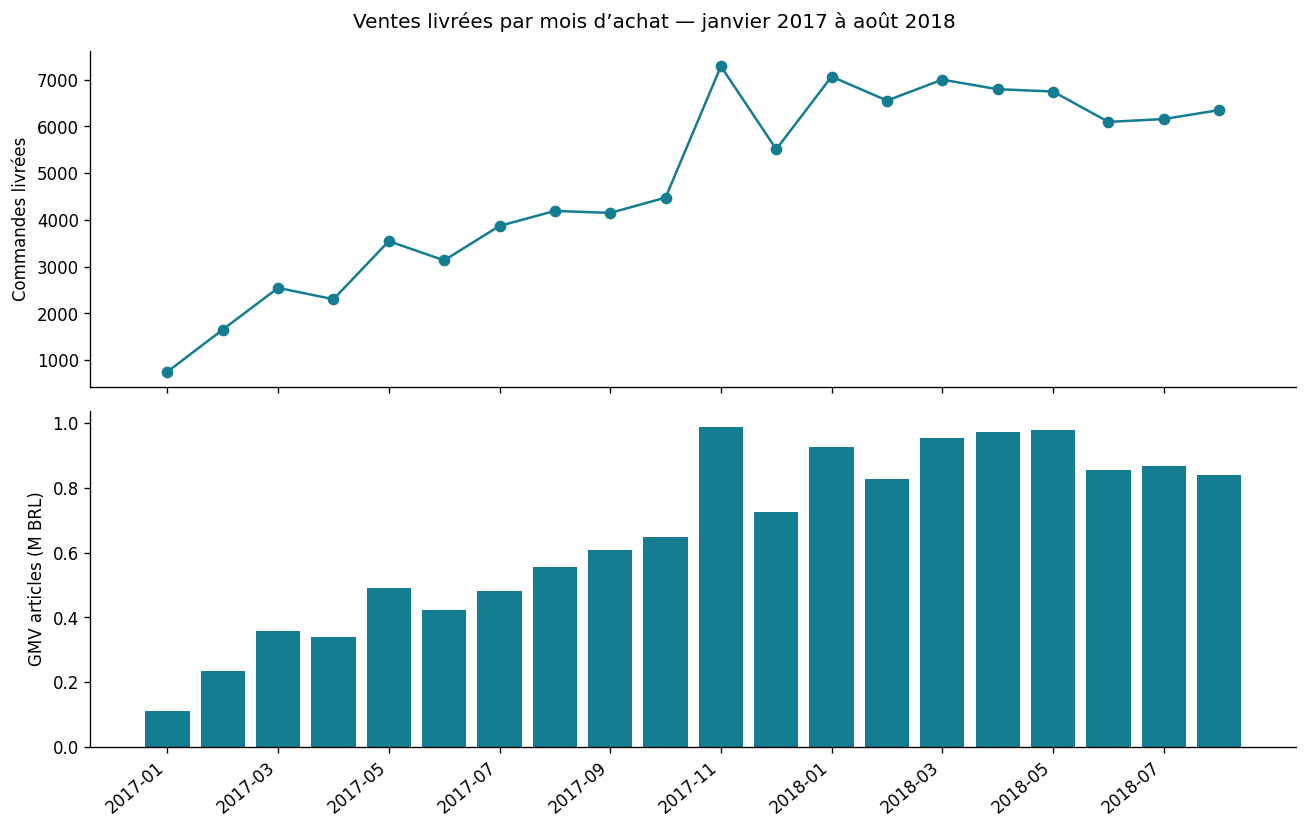

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
x = np.arange(len(monthly))
axes[0].plot(x, monthly.orders, marker='o', color='#147D92')
axes[0].set_ylabel('Commandes livrées')
axes[1].bar(x, monthly.gmv_brl / 1e6, color='#147D92')
axes[1].set_ylabel('GMV articles (M BRL)')
axes[1].set_xticks(x[::2])
axes[1].set_xticklabels(monthly.purchase_month.iloc[::2], rotation=40, ha='right')
fig.suptitle('Ventes livrées par mois d’achat — janvier 2017 à août 2018')
plt.tight_layout()
plt.show()

Comparer janvier–août d'une année à janvier–août de l'autre évite de comparer huit mois à douze mois. Une seule année complète ne suffit pas à établir une saisonnalité stable.

## 3. Jointures contrôlées

La vue SQL est reconstruite depuis les sources avec des CTE et `ROW_NUMBER`. Le dernier avis est choisi selon la date de réponse, puis création, identifiant et ordre source en cas d'égalité.

In [5]:
conn.executescript((BASE / 'sql/01_modele.sql').read_text(encoding='utf-8'))
recon = pd.read_sql_query('SELECT COUNT(*) AS rows, COUNT(DISTINCT order_id) AS unique_orders, SUM(item_value) AS gmv FROM v_order_summary', conn)
assert recon.loc[0, 'rows'] == recon.loc[0, 'unique_orders'] == len(orders)
assert np.isclose(recon.loc[0, 'gmv'], items.price.sum())
print(recon.to_string(index=False))

 rows  unique_orders        gmv
99441          99441 13591643.7


## 4. Tester l'association retard–satisfaction

Retard = réception un jour calendaire après la date promise ou plus. Un avis rédigé avant la réception ne peut pas évaluer une livraison terminée. Le test principal utilise les avis postérieurs à la réception et la première commande admissible par client. Cette sélection crée aussi un biais : la sensibilité à ce choix est présentée ensuite.

In [6]:
f = pd.read_csv(BASE / 'data/fact_orders.csv', parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date', 'review_answer_timestamp'])
rated = f[(f.analysis_period == 1) & (f.order_status == 'delivered') & f.is_late.notna() & f.review_score.notna() & (f.review_answer_timestamp >= f.order_delivered_customer_date)]
rated = rated.sort_values(['order_purchase_timestamp', 'order_id']).drop_duplicates('customer_unique_id')
late = rated.loc[rated.is_late == 1, 'review_score']
on_time = rated.loc[rated.is_late == 0, 'review_score']
test = stats.ttest_ind(late, on_time, equal_var=False)
print(f'Retard : {late.mean():.3f}, n={len(late)}')
print(f'A l heure : {on_time.mean():.3f}, n={len(on_time)}')
print(f'Ecart : {late.mean() - on_time.mean():.3f} point')
print(f'p brute Welch (bilatéral) : {test.pvalue:.3g}')
print('Lire la q-value corrigée et l’IC dans hypotheses.csv.')

Retard : 3.720, n=1854
A l heure : 4.289, n=86327
Ecart : -0.569 point
p brute Welch (bilatéral) : 9.83e-64
Lire la q-value corrigée et l’IC dans hypotheses.csv.


In [7]:
sensitivity = pd.read_csv(BASE / 'data/review_sensitivity.csv')
print(sensitivity.to_string(index=False))

                               population  is_late     n  review_score  bad_review_rate
                    Tous avis disponibles      0.0 89182      4.291157         0.092474
                    Tous avis disponibles      1.0  6378      2.270618         0.624177
       Avis apres reception, tous clients      0.0 89005      4.291793         0.092321
       Avis apres reception, tous clients      1.0  1907      3.719455         0.194546
Avis apres reception, un par client (H10)      0.0 86327      4.289017         0.092740
Avis apres reception, un par client (H10)      1.0  1854      3.719525         0.193635


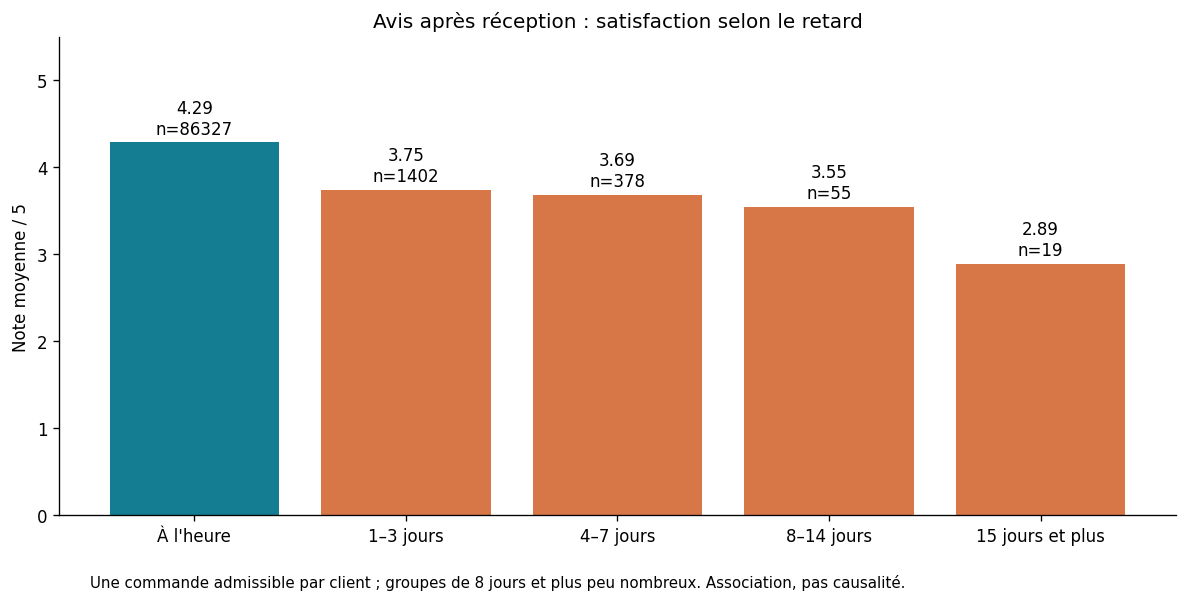

In [8]:
labels = ["À l'heure", '1–3 jours', '4–7 jours', '8–14 jours', '15 jours et plus']
delay_groups = pd.cut(rated.delay_days, [-np.inf, 0, 3, 7, 14, np.inf], labels=labels)
scores = rated.groupby(delay_groups, observed=True).review_score.agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scores.index.astype(str), scores['mean'], color=['#147D92'] + ['#D77748'] * 4)
for pos, row in enumerate(scores.itertuples()):
    ax.text(pos, row.mean + .1, f'{row.mean:.2f}\nn={row.count}', ha='center')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Note moyenne / 5')
ax.set_title('Avis après réception : satisfaction selon le retard')
fig.text(.08, .01, 'Une commande admissible par client ; groupes de 8 jours et plus peu nombreux. Association, pas causalité.', fontsize=9)
plt.tight_layout(rect=[0, .05, 1, 1])
plt.show()

La différence reste une association. Les produits, vendeurs, territoires et profils de clients ne sont pas assignés au hasard. Les tests exploratoires n'établissent pas un effet causal.

## 5. Concentration du GMV

Les prix sont additifs au niveau article. Les nombres de commandes distinctes par catégorie ne le sont pas : une commande peut contenir plusieurs catégories.

In [9]:
category_sql = "SELECT category, SUM(price) AS gmv FROM fact_items WHERE analysis_period=1 AND order_status='delivered' GROUP BY category ORDER BY gmv DESC"
category = pd.read_sql_query(category_sql, conn)
print(category.head(10).to_string(index=False))
print(f'Part du top 10 : {category.head(10).gmv.sum() / category.gmv.sum():.2%}')

             category        gmv
        health_beauty 1229557.50
        watches_gifts 1163465.91
       bed_bath_table 1022955.77
       sports_leisure  952840.40
computers_accessories  888055.59
      furniture_decor  706237.17
           housewares  614341.62
           cool_stuff  609158.00
                 auto  577838.39
         garden_tools  469135.40
Part du top 10 : 62.47%


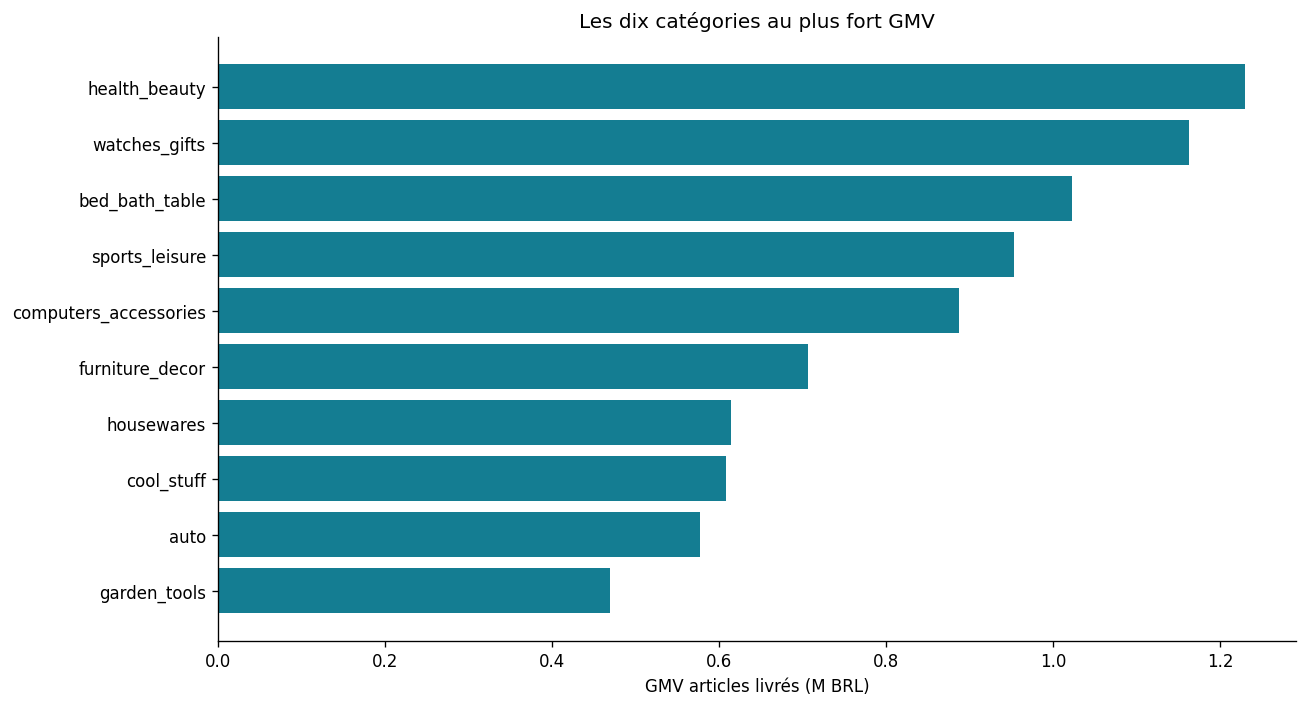

In [10]:
top = category.head(10).sort_values('gmv')
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top.category, top.gmv / 1e6, color='#147D92')
ax.set_xlabel('GMV articles livrés (M BRL)')
ax.set_title('Les dix catégories au plus fort GMV')
plt.tight_layout()
plt.show()

### Géographie, vendeurs et distributions


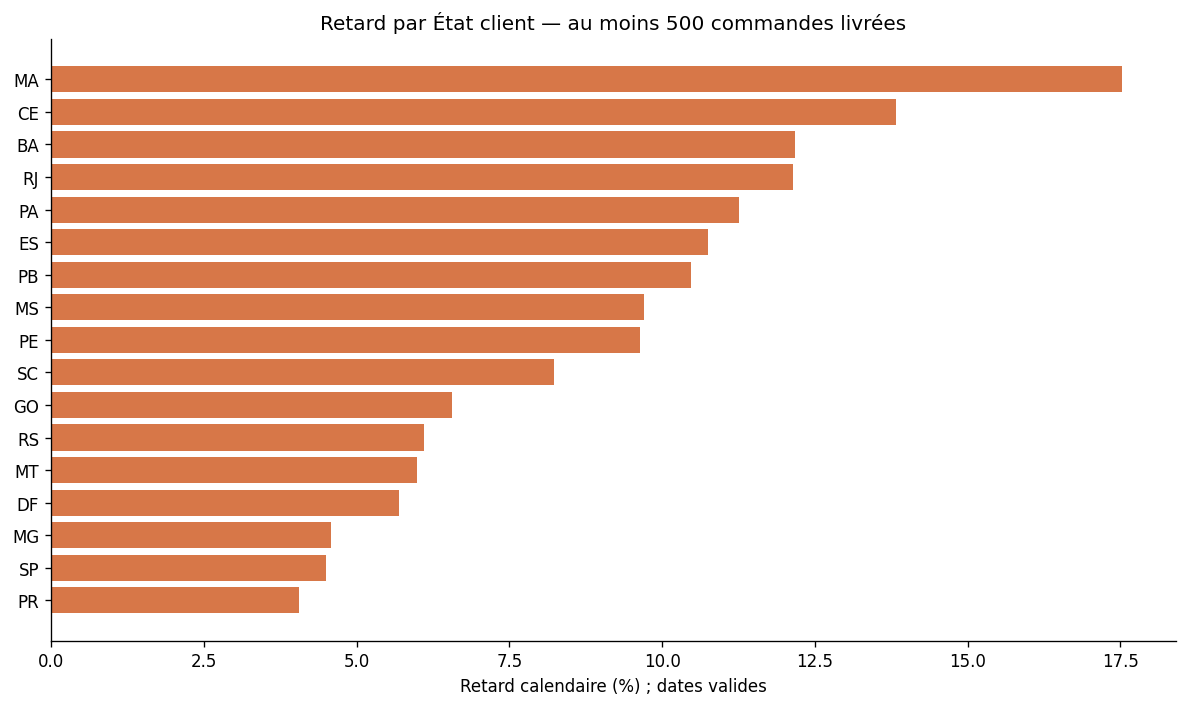

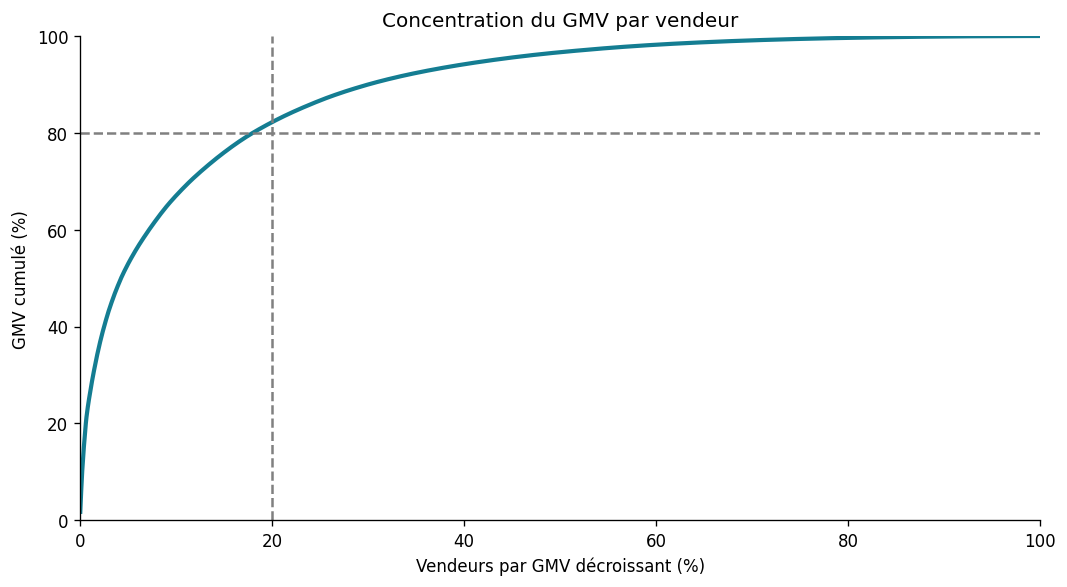

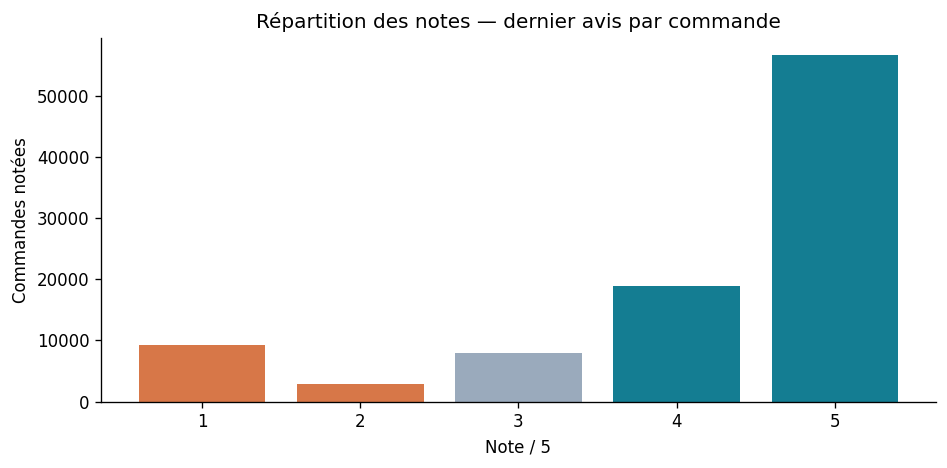

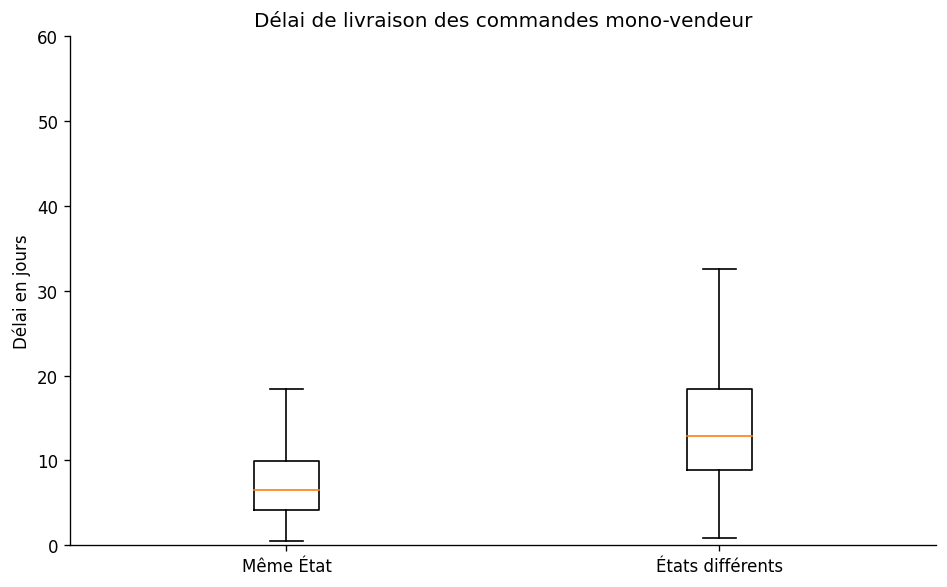

In [11]:
# Géographie : comparaison parmi les commandes livrées de la période.
delivered = f[(f.analysis_period == 1) & (f.order_status == 'delivered')]
states = delivered.groupby('customer_state').agg(orders=('order_id', 'size'), late_rate=('is_late', 'mean'))
states = states[states.orders >= 500].sort_values('late_rate')
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(states.index, states.late_rate * 100, color='#D77748')
ax.set_xlabel('Retard calendaire (%) ; dates valides')
ax.set_title('Retard par État client — au moins 500 commandes livrées')
plt.tight_layout()
plt.show()

# Concentration : prix agrégés par vendeur au grain article.
sellers = pd.read_sql_query("SELECT seller_id, SUM(price) AS gmv FROM fact_items WHERE analysis_period=1 AND order_status='delivered' GROUP BY seller_id ORDER BY gmv DESC", conn)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(sellers)+1)/len(sellers)*100, sellers.gmv.cumsum()/sellers.gmv.sum()*100, color='#147D92', linewidth=2.5)
ax.axvline(20, color='gray', linestyle='--')
ax.axhline(80, color='gray', linestyle='--')
ax.set(xlabel='Vendeurs par GMV décroissant (%)', ylabel='GMV cumulé (%)', title='Concentration du GMV par vendeur', xlim=(0, 100), ylim=(0, 100))
plt.tight_layout()
plt.show()

# Répartition des notes : toutes les notes des commandes livrées de la période.
scores_all = delivered.review_score.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(scores_all.index.astype(int), scores_all.values, color=['#D77748', '#D77748', '#9AAABC', '#147D92', '#147D92'])
ax.set(xlabel='Note / 5', ylabel='Commandes notées', title='Répartition des notes — dernier avis par commande')
ax.set_xticks(range(1, 6))
plt.tight_layout()
plt.show()

# Distribution du délai par zone ; zoom 0–60 jours, valeurs extrêmes masquées.
geo = delivered[delivered.seller_count.eq(1) & delivered.same_state.notna()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([geo.loc[geo.same_state.eq(1), 'delivery_days'].dropna(), geo.loc[geo.same_state.eq(0), 'delivery_days'].dropna()], labels=['Même État', 'États différents'], showfliers=False)
ax.set(ylim=(0, 60), ylabel='Délai en jours', title='Délai de livraison des commandes mono-vendeur')
plt.tight_layout()
plt.show()

## 6. Réachat avec 90 jours de suivi

Utiliser les premiers achats observés avant juin 2018 donne des cohortes mensuelles avec suivi complet au 31 août 2018. Un nouvel achat est une autre commande, passée après l'achat initial et au plus 90 jours plus tard, finalement livrée dans l'extrait. On ne mesure ni le churn ni la fidélité globale à Olist.

In [12]:
cohorts = pd.read_csv(BASE / 'data/cohorts_90.csv')
rate = cohorts.repeat_90.sum() / cohorts.customers.sum()
print(cohorts.to_string(index=False))
print(f'Reachat 90 jours pondéré par les clients : {rate:.2%}')

cohort_month  customers  repeat_90  repeat_rate_90
     2016-09          1          0        0.000000
     2016-10        262          3        0.011450
     2016-12          1          1        1.000000
     2017-01        717         22        0.030683
     2017-02       1628         26        0.015971
     2017-03       2503         56        0.022373
     2017-04       2256         42        0.018617
     2017-05       3451         86        0.024920
     2017-06       3037         77        0.025354
     2017-07       3752         82        0.021855
     2017-08       4057         95        0.023416
     2017-09       4004        100        0.024975
     2017-10       4328         86        0.019871
     2017-11       7060        143        0.020255
     2017-12       5338         81        0.015174
     2018-01       6842        130        0.019000
     2018-02       6288        163        0.025922
     2018-03       6774        115        0.016977
     2018-04       6582        

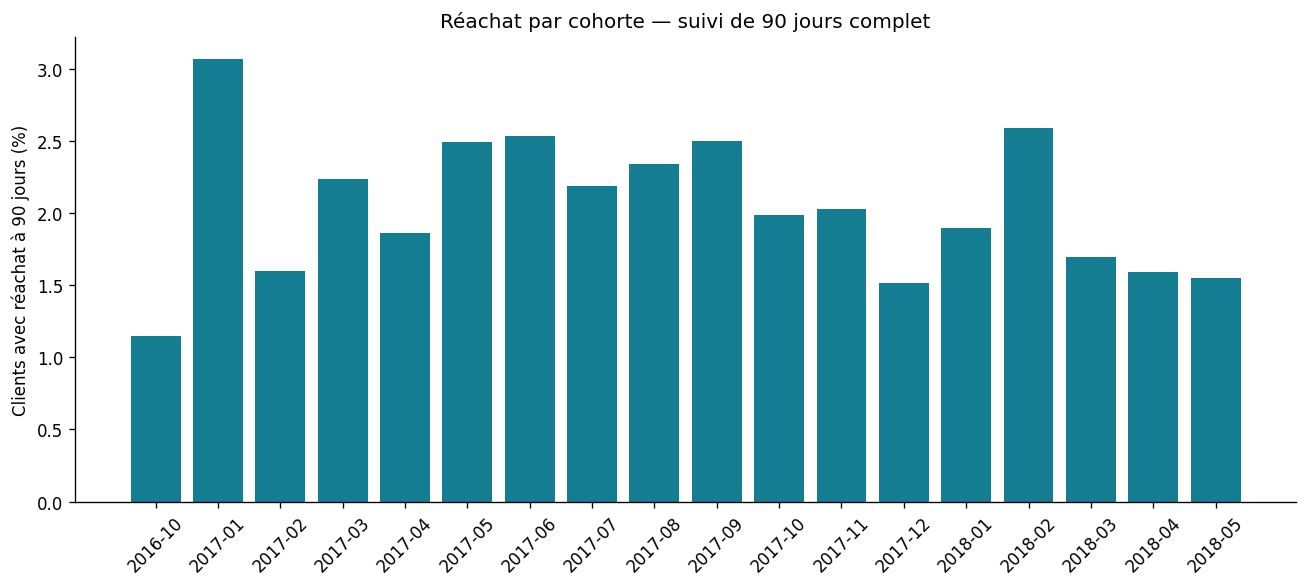

In [13]:
eligible_cohorts = cohorts[cohorts.customers >= 100]
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(eligible_cohorts.cohort_month, eligible_cohorts.repeat_rate_90 * 100, color='#147D92')
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Clients avec réachat à 90 jours (%)')
ax.set_title('Réachat par cohorte — suivi de 90 jours complet')
plt.tight_layout()
plt.show()

## 7. Résultats des hypothèses et limites

Les p-values des tests inférentiels sont corrigées ensemble avec Benjamini–Hochberg. Les IC à 95 % de différences de moyennes ne sont pas des intervalles simultanés. Les seuils descriptifs sont exploratoires et explicités ; ils ne reçoivent pas de p-value.

In [14]:
hyp = pd.read_csv(BASE / 'data/hypotheses.csv')
print(hyp[['id', 'hypothese', 'conclusion', 'effect', 'q_bh']].to_string(index=False))
assert len(hyp) == 26
conn.close()

 id                                                                                            hypothese                       conclusion     effect          q_bh
H01                                Le volume livre augmente entre janvier-aout 2017 et janvier-aout 2018                         Observee        NaN           NaN
H02                                                 Le panier articles moyen augmente sur les memes mois                         Observee        NaN           NaN
H03                                               Novembre est le mois au plus fort volume livre en 2017                         Observee        NaN           NaN
H04                                                Le volume quotidien moyen est plus faible le week-end                         Observee        NaN           NaN
H05                                            Dix categories concentrent plus de la moitie du GMV livre                         Observee        NaN           NaN
H06                   

## 8. Passage à Power BI

Le projet natif ../powerbi/Olist/Olist.pbip contient quatre pages avec graphiques, indicateurs et filtres, sept tables et 27 mesures DAX. Instructions : ../powerbi/OUVRIR_POWER_BI.md. Structure validee ; actualisation, evaluation DAX et rendu Desktop restent a verifier avant enregistrement PBIX.

## Recommandations

Prioriser l'audit des commandes multi-vendeurs et des promesses de livraison, segmenter les performances logistiques par territoire et distance, puis tester une action de réachat sur un groupe témoin. Aucun gain financier causal n'est estimé à partir de ces associations.